# 2-Triangle Constraint Optimization - Jacobian Method Comparison

Companion to [../shoelace-artifact-example.ipynb](../shoelace-artifact-example.ipynb). Uses the same 7x7 bowtie field (`dx[3,3]=+1.2, dx[3,4]=-1.2`). Every run here uses the **same 2-triangle constraint**; what varies is how the solver's inner QP gets the constraint Jacobian:

1. **(A) 2tri + finite-diff Jac** - scipy's default numerical Jacobian via 2-point finite differences on the constraint function.
2. **(B) 2tri + analytical Jac** - closed-form `triangle_sign_constraint_jac_2d` plugged into `NonlinearConstraint(..., jac=...)`.
3. **(C) 2tri + analytical + warm-start** - same as (B) plus a small Gaussian perturbation + resume, the fix from `05_solver-engineering.ipynb` that unsticks SLSQP when it hits status 8.

For a cross-constraint comparison (CD vs FD vs 2-tri), see [04_constraint-comparison.ipynb](04_constraint-comparison.ipynb).

Color convention: red = positive Jdet / valid triangle, blue = negative / fold (`RdBu_r`).

In [1]:
import os, sys, time
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, NonlinearConstraint
from scipy.sparse import csr_matrix

from dvfopt import DEFAULT_PARAMS, jacobian_det2D
from dvfopt.jacobian import triangle_sign_det2D, triangle_sign_areas2D
from dvfopt.jacobian.numpy_jdet import _numpy_jdet_2d
from dvfopt.jacobian.triangle_sign import _triangle_areas_2d
from dvfopt.core.objective import objective_euc
from dvfopt.viz import plot_problematic_triangles, plot_triangle_debug
from dvfopt.viz.triangle_debug import find_problematic_pixels

THRESHOLD = DEFAULT_PARAMS['threshold']  # 0.01
print(f'threshold = {THRESHOLD}')


def _forward_jdet_2d(dy, dx):
    ddx_dx = dx[:-1, 1:]  - dx[:-1, :-1]
    ddy_dy = dy[1:,  :-1] - dy[:-1, :-1]
    ddx_dy = dx[1:,  :-1] - dx[:-1, :-1]
    ddy_dx = dy[:-1, 1:]  - dy[:-1, :-1]
    return (1 + ddx_dx) * (1 + ddy_dy) - ddx_dy * ddy_dx

threshold = 0.01


## Test field — the shoelace-artifact bowtie

Same construction as `shoelace-artifact-example.ipynb`: a 7×7 grid, zero everywhere except `dx[3, 3] = +1.2` and `dx[3, 4] = −1.2`. Central-diff Jdet is all-positive (min +0.4) but two quad cells are folded.

In [2]:
H = W = 7
dy0 = np.zeros((H, W))
dx0 = np.zeros((H, W))
dx0[3, 3] = +1.2
dx0[3, 4] = -1.2
phi0 = np.stack([dy0, dx0])

def report(phi, label):
    jd = np.squeeze(jacobian_det2D(phi))
    fd = _forward_jdet_2d(phi[0], phi[1])
    tri = triangle_sign_areas2D(phi)
    return {
        'label': label,
        'jd': jd, 'fd': fd, 'tri': tri,
        'n_cd': int((jd <= 0).sum()),
        'n_fd': int((fd <= 0).sum()),
        'n_tr': int((tri <= 0).sum()),
        'min_cd': float(jd.min()), 'min_fd': float(fd.min()), 'min_tr': float(tri.min()),
        'l2': float(np.linalg.norm(phi - phi0)),
    }

r0 = report(phi0, 'initial (no correction)')
print(f"{'measure':<22s}  {'n_neg':>6s}  {'min':>8s}")
print('-' * 42)
print(f"{'central-diff Jdet':<22s}  {r0['n_cd']:>6d}  {r0['min_cd']:+8.3f}")
print(f"{'forward-diff Jdet':<22s}  {r0['n_fd']:>6d}  {r0['min_fd']:+8.3f}")
print(f"{'2-triangle areas':<22s}  {r0['n_tr']:>6d}  {r0['min_tr']:+8.3f}")

measure                  n_neg       min
------------------------------------------
central-diff Jdet            0    +0.400
forward-diff Jdet            1    -1.400
2-triangle areas             2    -0.700


### The bowtie, pre-optimization

Three views of the initial field:

- **Left** — warped quad grid. Two bowtie quads at cells `(3, 3)` and `(3, 4)` where `dx[3, 3] = +1.2` swaps its pixel with `dx[3, 4] = −1.2`. Each quad has crossed top/bottom edges (self-intersecting), which is exactly a fold.
- **Middle** — central-diff Jacobian `jacobian_det2D(phi)`. Uniformly red (all-positive pixel Jdet, `min = +0.40`) — the symmetric 2Δ stencil **cannot see** the fold.
- **Right** — `min(T1, T2)` of the 2-triangle per-cell check. Clearly blue on the two folded cells. This is what 2-triangle SLSQP will be asked to drive positive.

Establishes the setup: a case where central-diff is blind and the geometric check flags the problem.

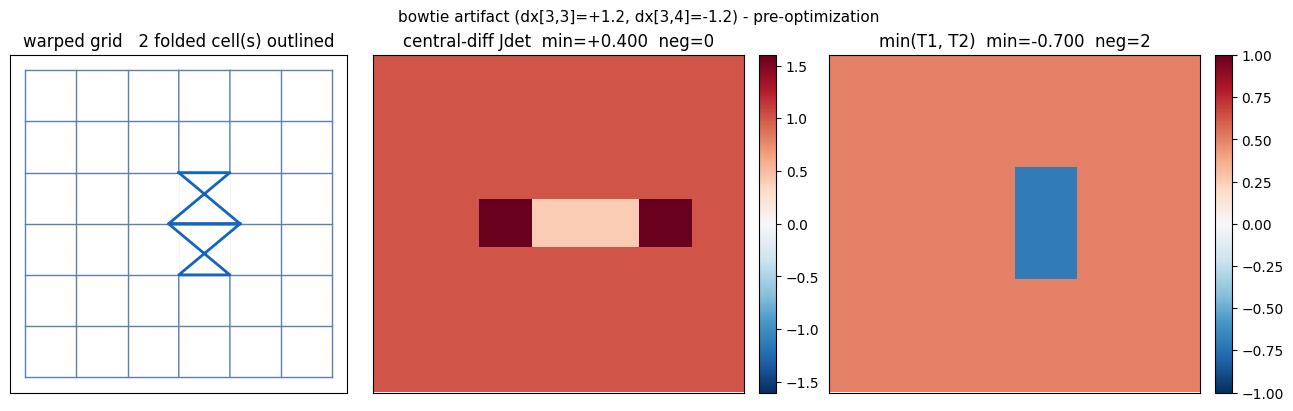

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), layout='constrained')

# --- warped grid -----------------------------------------------------
ax = axes[0]
yy, xx = np.mgrid[:H, :W]
gx = xx + dx0; gy = yy + dy0
for i in range(H):
    ax.plot(xx[i], yy[i], color='#f0f0f0', lw=0.5)
for j in range(W):
    ax.plot(xx[:, j], yy[:, j], color='#f0f0f0', lw=0.5)
for i in range(H):
    ax.plot(gx[i], gy[i], color='#5b7fb5', lw=1.0)
for j in range(W):
    ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=1.0)
# outline the folded cells in dark blue
tri0 = triangle_sign_areas2D(phi0)
bad = np.argwhere(tri0.min(axis=0) <= 0)
for (cy, cx) in bad:
    poly_x = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
    poly_y = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
    ax.plot(poly_x, poly_y, color='#1565c0', lw=2.0)
ax.set_aspect('equal'); ax.invert_yaxis()
ax.set_title(f'warped grid   {len(bad)} folded cell(s) outlined')
ax.set_xticks([]); ax.set_yticks([])

# --- central-diff Jdet heatmap --------------------------------------
jd0 = np.squeeze(jacobian_det2D(phi0))
vmax_cd = float(max(abs(jd0).max(), 1.0))
im1 = axes[1].imshow(jd0, cmap='RdBu_r', vmin=-vmax_cd, vmax=vmax_cd, aspect='auto')
axes[1].set_title(f'central-diff Jdet  min={r0["min_cd"]:+.3f}  neg={r0["n_cd"]}')
axes[1].set_xticks([]); axes[1].set_yticks([])
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- 2-triangle min heatmap -----------------------------------------
tri_min0 = tri0.min(axis=0)
vmax_tr = float(max(abs(tri_min0).max(), 1.0))
im2 = axes[2].imshow(tri_min0, cmap='RdBu_r', vmin=-vmax_tr, vmax=vmax_tr, aspect='auto')
axes[2].set_title(f'min(T1, T2)  min={r0["min_tr"]:+.3f}  neg={r0["n_tr"]}')
axes[2].set_xticks([]); axes[2].set_yticks([])
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle('bowtie artifact (dx[3,3]=+1.2, dx[3,4]=-1.2) - pre-optimization', fontsize=11)
plt.show()

## Solver

Full-grid SLSQP: `2*H*W` variables packed as `z = [dx_flat | dy_flat]`, quadratic data term `1/2 ||phi - phi_init||^2`, single nonlinear constraint vector = per-cell 2-triangle signed areas. The only thing that differs between the three runs is the `jac` argument passed to `NonlinearConstraint`.

In [4]:
def _triangle_flat(dy_, dx_):
    T1, T2 = _triangle_areas_2d(dy_, dx_)
    return np.concatenate([T1.flatten(), T2.flatten()])


def triangle_sign_constraint_jac_2d(dy, dx):
    '''Analytical sparse Jacobian ∂g/∂z of the 2-triangle constraint.'''
    H_, W_ = dy.shape
    nr, nc = H_ - 1, W_ - 1
    N = H_ * W_
    ref_y, ref_x = np.mgrid[:H_, :W_]
    X = ref_x + dx; Y = ref_y + dy
    TLx, TLy = X[:-1, :-1], Y[:-1, :-1]
    TRx, TRy = X[:-1, 1:],  Y[:-1, 1:]
    BLx, BLy = X[1:,  :-1], Y[1:,  :-1]
    BRx, BRy = X[1:,  1:],  Y[1:,  1:]
    cy_grid, cx_grid = np.mgrid[:nr, :nc]
    cy = cy_grid.ravel(); cx = cx_grid.ravel()
    def dx_idx(py, px): return py * W_ + px
    def dy_idx(py, px): return N + py * W_ + px
    n_cells = nr * nc
    rows_T1 = np.arange(n_cells)
    T1_rows = np.tile(rows_T1, 6)
    T1_cols = np.concatenate([
        dx_idx(cy, cx + 1), dy_idx(cy, cx + 1),
        dx_idx(cy + 1, cx), dy_idx(cy + 1, cx),
        dx_idx(cy + 1, cx + 1), dy_idx(cy + 1, cx + 1),
    ])
    T1_vals = np.concatenate([
        0.5 * (BRy - BLy).ravel(), 0.5 * (BLx - BRx).ravel(),
        0.5 * (TRy - BRy).ravel(), 0.5 * (BRx - TRx).ravel(),
        0.5 * (BLy - TRy).ravel(), 0.5 * (TRx - BLx).ravel(),
    ])
    rows_T2 = np.arange(n_cells) + n_cells
    T2_rows = np.tile(rows_T2, 6)
    T2_cols = np.concatenate([
        dx_idx(cy, cx),          dy_idx(cy, cx),
        dx_idx(cy + 1, cx),      dy_idx(cy + 1, cx),
        dx_idx(cy, cx + 1),      dy_idx(cy, cx + 1),
    ])
    T2_vals = np.concatenate([
        0.5 * (TRy - BLy).ravel(), 0.5 * (BLx - TRx).ravel(),
        0.5 * (TLy - TRy).ravel(), 0.5 * (TRx - TLx).ravel(),
        0.5 * (BLy - TLy).ravel(), 0.5 * (TLx - BLx).ravel(),
    ])
    rows = np.concatenate([T1_rows, T2_rows])
    cols = np.concatenate([T1_cols, T2_cols])
    vals = np.concatenate([T1_vals, T2_vals])
    return csr_matrix((vals, (rows, cols)), shape=(2 * n_cells, 2 * N))


def run_2tri_slsqp(phi_init, use_analytical_jac=False, warm_start=False,
                    threshold=THRESHOLD, max_iter=500):
    _, H_, W_ = phi_init.shape
    pixels = H_ * W_
    dy, dx = phi_init[0], phi_init[1]
    z0 = np.concatenate([dx.flatten(), dy.flatten()])
    z0_init = z0.copy()

    def unpack(z):
        dx_ = z[:pixels].reshape(H_, W_)
        dy_ = z[pixels:].reshape(H_, W_)
        return dy_, dx_

    def constr(z):
        return _triangle_flat(*unpack(z))

    def constr_jac(z):
        dy_, dx_ = unpack(z)
        return triangle_sign_constraint_jac_2d(dy_, dx_)

    nl_kwargs = dict(lb=threshold, ub=np.inf)
    if use_analytical_jac:
        nl_kwargs['jac'] = constr_jac

    t0 = time.time()
    res = minimize(
        lambda z: objective_euc(z, z0_init),
        z0, jac=True, method='SLSQP',
        constraints=[NonlinearConstraint(constr, **nl_kwargs)],
        options={'maxiter': max_iter, 'disp': False},
    )
    total_nit = res.nit
    total_time = time.time() - t0

    # Optional warm-start retry if SLSQP stalled with status 8 (positive
    # directional derivative for linesearch).
    if warm_start and not res.success and res.status == 8:
        rng = np.random.default_rng(123)
        z_warm = res.x + rng.normal(scale=0.01, size=res.x.shape)
        t1 = time.time()
        res = minimize(
            lambda z: objective_euc(z, z0_init),
            z_warm, jac=True, method='SLSQP',
            constraints=[NonlinearConstraint(constr, **nl_kwargs)],
            options={'maxiter': 2000, 'ftol': 1e-10, 'disp': False},
        )
        total_nit += res.nit
        total_time += time.time() - t1

    dy_out, dx_out = unpack(res.x)
    phi_out = np.stack([dy_out, dx_out])
    r = report(phi_out, 'SLSQP[2-tri]')
    r.update(t=total_time, nit=total_nit, success=bool(res.success),
             status=int(res.status), message=str(res.message), phi=phi_out)
    return r

In [5]:
runs = {
    '(A) finite-diff Jac':         run_2tri_slsqp(phi0, use_analytical_jac=False, warm_start=False),
    '(B) analytical Jac':          run_2tri_slsqp(phi0, use_analytical_jac=True,  warm_start=False),
    '(C) analytical + warm-start': run_2tri_slsqp(phi0, use_analytical_jac=True,  warm_start=True),
}

hdr = f"{'variant':<32s}  {'nit':>4s}  {'time':>6s}  {'neg_TR':>6s}  {'min_TR':>8s}  {'L2':>6s}  success"
print(hdr)
print('-' * len(hdr))
print(f"{'initial':<32s}  {'-':>4s}  {'-':>6s}  {r0['n_tr']:>6d}  {r0['min_tr']:+8.3f}  {r0['l2']:>6.3f}")
for key, r in runs.items():
    print(
        f"{key:<32s}  {r['nit']:>4d}  {r['t']:>6.3f}  "
        f"{r['n_tr']:>6d}  {r['min_tr']:+8.3f}  {r['l2']:>6.3f}  {r['success']}"
    )

variant                            nit    time  neg_TR    min_TR      L2  success
---------------------------------------------------------------------------------
initial                              -       -       2    -0.700   0.000
(A) finite-diff Jac                  6   0.020       0    +0.010   0.853  True
(B) analytical Jac                   6   0.005       0    +0.010   0.853  True
(C) analytical + warm-start          6   0.004       0    +0.010   0.853  True


## Visual comparison

Four rows (initial + three variants), two columns: warped quad grid with folded cells outlined, and the per-cell `min(T1, T2)` signed-area heatmap. All three variants use the 2-triangle constraint, so the only differences in the corrected fields come from numerical noise in the Jacobian + whether the warm-start fired.

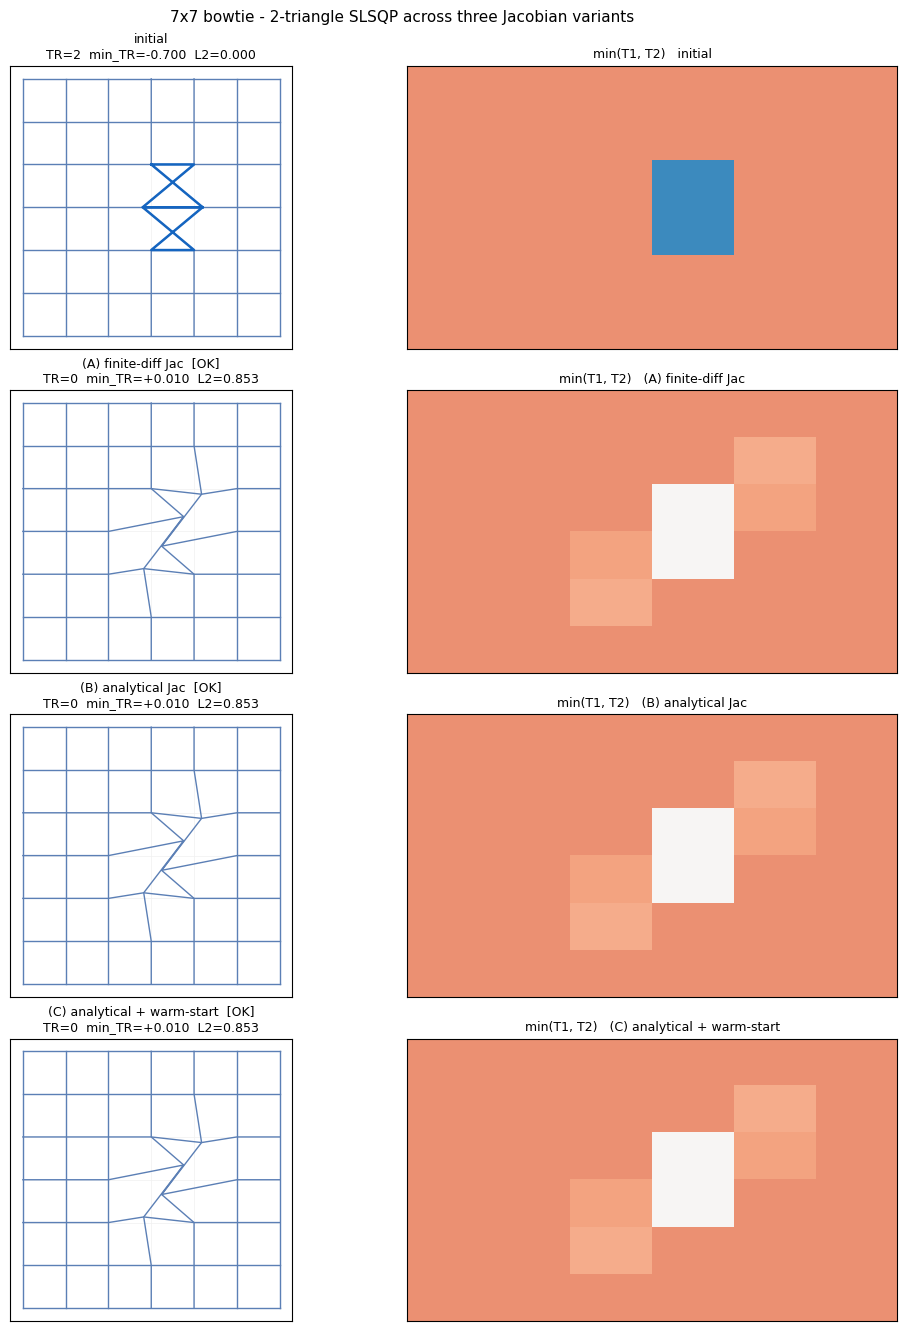

In [6]:
all_rows = [('initial', r0)] + list(runs.items())

vmax_tri = max(abs(r['tri']).max() for _, r in all_rows)
NL = chr(10)

def plot_warped_grid(ax, phi, title, highlight_folds=True):
    dy = phi[0]; dx = phi[1]
    Hh, Ww = dy.shape
    yy, xx = np.mgrid[:Hh, :Ww]
    gx = xx + dx; gy = yy + dy
    for i in range(Hh):
        ax.plot(xx[i], yy[i], color='#f0f0f0', lw=0.5)
    for j in range(Ww):
        ax.plot(xx[:, j], yy[:, j], color='#f0f0f0', lw=0.5)
    for i in range(Hh):
        ax.plot(gx[i], gy[i], color='#5b7fb5', lw=1.0)
    for j in range(Ww):
        ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=1.0)
    if highlight_folds:
        tri = triangle_sign_areas2D(phi)
        bad = np.argwhere(tri.min(axis=0) <= 0)
        for (cy, cx) in bad:
            px = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
            py = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
            ax.plot(px, py, color='#1565c0', lw=1.8)
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])


fig, axes = plt.subplots(len(all_rows), 2, figsize=(10, 3.3 * len(all_rows)), layout='constrained')
for i, (label, r) in enumerate(all_rows):
    phi = phi0 if label == 'initial' else r['phi']
    if label == 'initial':
        line1 = label
    else:
        tag = 'OK' if r['success'] else 'FAIL'
        line1 = f"{label}  [{tag}]"
    line2 = f"TR={r['n_tr']}  min_TR={r['min_tr']:+.3f}  L2={r['l2']:.3f}"
    plot_warped_grid(axes[i, 0], phi, line1 + NL + line2)

    tri_min = r['tri'].min(axis=0)
    im = axes[i, 1].imshow(tri_min, cmap='RdBu_r', vmin=-vmax_tri, vmax=vmax_tri, aspect='auto')
    axes[i, 1].set_title(f'min(T1, T2)   {label}', fontsize=9)
    axes[i, 1].set_xticks([]); axes[i, 1].set_yticks([])

plt.suptitle('7x7 bowtie - 2-triangle SLSQP across three Jacobian variants', fontsize=11)
plt.show()

## Per-pixel debug inspection

For every pixel that's problematic in *any* variant, show its T1/T2 across (initial, (A), (B), (C)). On the bowtie the two problematic pixels are `(3, 3)` and `(4, 2)` in the initial state; all three 2-tri variants should clear them.

2 pixel(s) problematic in at least one variant: [(3, 3), (4, 2)]


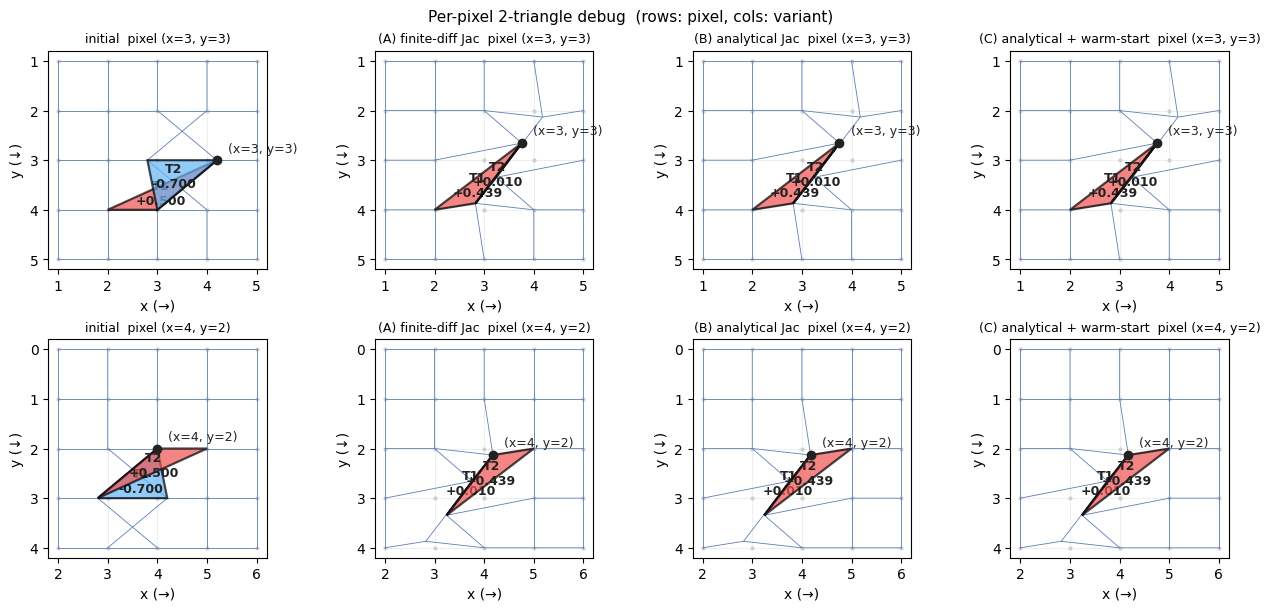

In [7]:
labels = [('initial', phi0)] + [(k, v['phi']) for k, v in runs.items()]

all_bad = set()
for _, phi in labels:
    all_bad.update(find_problematic_pixels(phi))
all_bad = sorted(all_bad)
print(f'{len(all_bad)} pixel(s) problematic in at least one variant: {all_bad}')

if all_bad:
    fig, axes = plt.subplots(len(all_bad), len(labels),
                              figsize=(3.2 * len(labels), 3.0 * len(all_bad)),
                              layout='constrained', squeeze=False)
    for row, (x, y) in enumerate(all_bad):
        for col, (label, phi) in enumerate(labels):
            plot_triangle_debug(phi, x=x, y=y, ax=axes[row, col], show_formula=False)
            axes[row, col].set_title(f'{label}  pixel (x={x}, y={y})', fontsize=9)
    plt.suptitle('Per-pixel 2-triangle debug  (rows: pixel, cols: variant)', fontsize=11)
    plt.show()
else:
    print('No problematic pixels across any variant.')

## Summary

- All three variants hold the same 2-triangle constraint; only the Jacobian source (and the warm-start) changes.
- On the 7x7 bowtie, all three converge to `neg_TR=0` in well under a second. Differences are purely in iteration count / wall time.
- Warm-start doesn't fire here (SLSQP succeeds on the first attempt), so (B) and (C) produce identical outputs; the branch is retained in case future runs include harder cases where SLSQP stalls.
- For a direct comparison against central-diff and forward-diff *constraint* formulations (not just different Jacobians of the 2-triangle constraint), open [04_constraint-comparison.ipynb](04_constraint-comparison.ipynb).